# GMM Regime Classification Backtesting

This notebook focuses on developing and backtesting a Gaussian Mixture Model (GMM) based regime classifier for volatility surface analysis. We'll use extended historical data to train more robust models.

## 1. Load Extended Historical Data

We'll use synthetic data spanning 20+ years to train the GMM with diverse market conditions.

In [9]:
# Ensure project root is in sys.path for dashboard.app import
import sys
sys.path.insert(0, '..')

from dashboard import load_synthetic_historical_data
# Load extended historical data

print("Loading extended historical dataset...")
historical_data = load_synthetic_historical_data()

print(f"Dataset shape: {historical_data.shape}")
print(f"Date range: {historical_data.index.min()} to {historical_data.index.max()}")
print(f"Duration: {(historical_data.index.max() - historical_data.index.min()).days} days")

# Display basic statistics
print("\nBasic Statistics:")
print(historical_data.describe())

Loading extended historical dataset...
Dataset shape: (8000, 11)
Date range: 1995-05-31 15:20:31.931132 to 2026-01-27 15:20:31.931132
Duration: 11199 days

Basic Statistics:
       avg_atm_vol  avg_atm_curvature  avg_butterfly  avg_25d_skew  \
count  8000.000000        8000.000000    8000.000000   8000.000000   
mean      0.166647           0.054686       0.028251     -0.063411   
std       0.061119           0.033339       0.019383      0.044890   
min       0.059031           0.000000       0.000000     -0.284421   
25%       0.123411           0.030696       0.015297     -0.086128   
50%       0.148040           0.044452       0.021825     -0.046173   
75%       0.192865           0.071648       0.035840     -0.030656   
max       0.464738           0.208666       0.147055      0.010731   

         roughness  unemployment_rate  fed_funds_rate  treasury_10y  \
count  8000.000000        8000.000000     8000.000000   8000.000000   
mean      0.061230           4.625376        2.245592

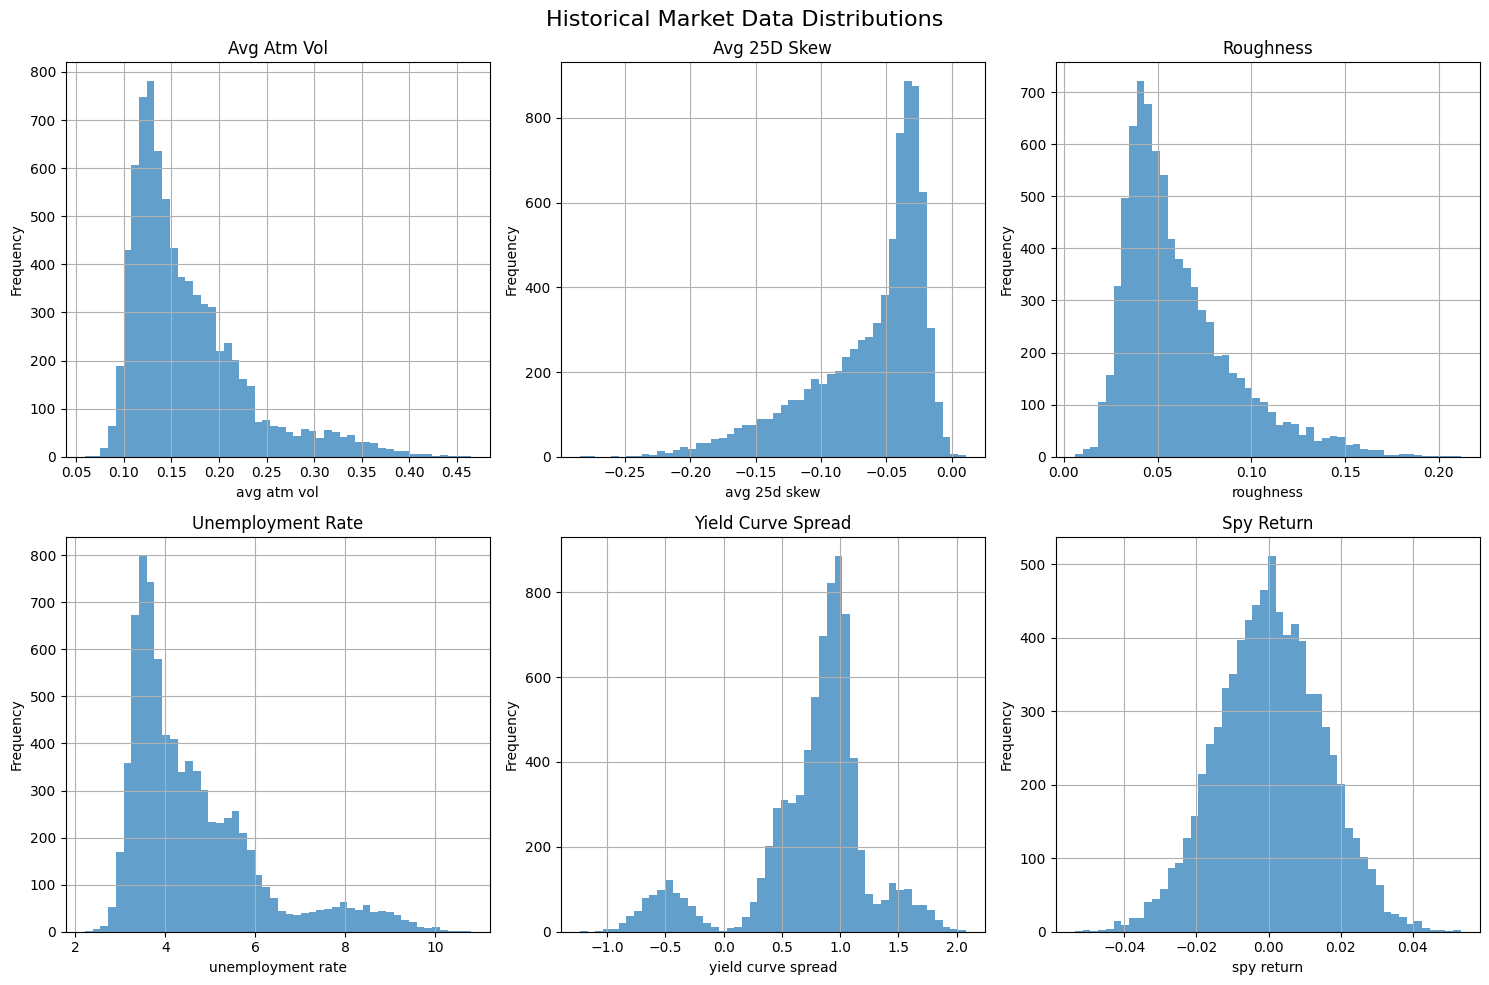

In [10]:
# Visualize the historical data distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Historical Market Data Distributions', fontsize=16)

features = ['avg_atm_vol', 'avg_25d_skew', 'roughness', 'unemployment_rate', 'yield_curve_spread', 'spy_return']

for i, feature in enumerate(features):
    ax = axes[i//3, i%3]
    historical_data[feature].hist(bins=50, ax=ax, alpha=0.7)
    ax.set_title(f'{feature.replace("_", " ").title()}')
    ax.set_xlabel(feature.replace("_", " "))
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 2. GMM Model Development

Let's experiment with different GMM configurations and feature sets.

In [11]:
# Test different feature combinations
feature_sets = {
    'volatility_only': ['avg_atm_vol', 'roughness'],
    'volatility_surface': ['avg_atm_vol', 'avg_25d_skew', 'roughness', 'avg_atm_curvature'],
    'market_context': ['avg_atm_vol', 'unemployment_rate', 'yield_curve_spread', 'spy_return'],
    'comprehensive': ['avg_atm_vol', 'avg_25d_skew', 'roughness', 'unemployment_rate', 'yield_curve_spread', 'spy_return']
}

results = {}

for name, features in feature_sets.items():
    print(f"\nTesting feature set: {name}")
    print(f"Features: {features}")
    
    # Filter data to available features
    available_features = [f for f in features if f in historical_data.columns]
    if len(available_features) != len(features):
        print(f"Warning: Some features not available. Using: {available_features}")
    
    data_subset = historical_data[available_features].dropna()
    
    if len(data_subset) < 1000:
        print(f"Insufficient data for {name}: {len(data_subset)} samples")
        continue
    
    # Initialize and fit GMM
    gmm = GMMRegimeClassifier(n_components=5, random_state=42, feature_cols=available_features)
    gmm.fit(data_subset)
    
    # Calculate BIC and AIC for model selection
    from sklearn.mixture import GaussianMixture
    scaler = gmm.scaler
    scaled_data = scaler.transform(data_subset.values)
    
    bic = gmm.gmm.bic(scaled_data)
    aic = gmm.gmm.aic(scaled_data)
    log_likelihood = gmm.gmm.score(scaled_data)
    
    results[name] = {
        'features': available_features,
        'n_samples': len(data_subset),
        'bic': bic,
        'aic': aic,
        'log_likelihood': log_likelihood,
        'gmm': gmm
    }
    
    print(f"Samples: {len(data_subset)}")
    print(f"BIC: {bic:.2f}, AIC: {aic:.2f}")
    print(f"Average Log Likelihood: {log_likelihood:.4f}")


Testing feature set: volatility_only
Features: ['avg_atm_vol', 'roughness']


2026-01-27 15:20:38.363 | INFO     | analytics.regime_classifier:fit:475 - GMM fitted with 5 components on 8000 samples
2026-01-27 15:20:38.420 | INFO     | analytics.regime_classifier:fit:475 - GMM fitted with 5 components on 8000 samples
2026-01-27 15:20:38.539 | INFO     | analytics.regime_classifier:fit:475 - GMM fitted with 5 components on 8000 samples


Samples: 8000
BIC: 33145.03, AIC: 32942.40
Average Log Likelihood: -2.0553

Testing feature set: volatility_surface
Features: ['avg_atm_vol', 'avg_25d_skew', 'roughness', 'avg_atm_curvature']
Samples: 8000
BIC: 54479.25, AIC: 53962.20
Average Log Likelihood: -3.3634

Testing feature set: market_context
Features: ['avg_atm_vol', 'unemployment_rate', 'yield_curve_spread', 'spy_return']
Samples: 8000
BIC: 55635.95, AIC: 55118.90
Average Log Likelihood: -3.4357

Testing feature set: comprehensive
Features: ['avg_atm_vol', 'avg_25d_skew', 'roughness', 'unemployment_rate', 'yield_curve_spread', 'spy_return']


2026-01-27 15:20:38.648 | INFO     | analytics.regime_classifier:fit:475 - GMM fitted with 5 components on 8000 samples


Samples: 8000
BIC: 75677.90, AIC: 74706.68
Average Log Likelihood: -4.6518


In [12]:
# Compare model performance
comparison_df = pd.DataFrame({
    name: {
        'BIC': results[name]['bic'],
        'AIC': results[name]['aic'],
        'Log Likelihood': results[name]['log_likelihood'],
        'Features': len(results[name]['features']),
        'Samples': results[name]['n_samples']
    }
    for name in results.keys()
}).T

print("Model Comparison:")
print(comparison_df.round(2))

# Visualize BIC comparison
fig = go.Figure()
fig.add_trace(go.Bar(
    x=comparison_df.index,
    y=comparison_df['BIC'],
    name='BIC',
    marker_color='lightblue'
))
fig.update_layout(
    title='BIC Comparison Across Feature Sets',
    xaxis_title='Feature Set',
    yaxis_title='BIC (lower is better)',
    showlegend=False
)
fig.show()

Model Comparison:
                         BIC       AIC  Log Likelihood  Features  Samples
volatility_only     33145.03  32942.40           -2.06       2.0   8000.0
volatility_surface  54479.25  53962.20           -3.36       4.0   8000.0
market_context      55635.95  55118.90           -3.44       4.0   8000.0
comprehensive       75677.90  74706.68           -4.65       6.0   8000.0


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [13]:
# Print summary and highlight best feature set
best_model_name = comparison_df['BIC'].idxmin()
best_metrics = comparison_df.loc[best_model_name]

print("\n=== Feature Set Backtest Summary ===")
display_cols = ['BIC', 'AIC', 'Log Likelihood', 'Features', 'Samples']
display_df = comparison_df[display_cols].sort_values('BIC')
print(display_df)
print(f"\nBest Feature Set: {best_model_name}")
print(f"BIC: {best_metrics['BIC']:.2f}, AIC: {best_metrics['AIC']:.2f}, Log Likelihood: {best_metrics['Log Likelihood']:.4f}")
print(f"Features: {results[best_model_name]['features']}")


=== Feature Set Backtest Summary ===
                             BIC           AIC  Log Likelihood  Features  \
volatility_only     33145.032810  32942.404102       -2.055275       2.0   
volatility_surface  54479.252394  53962.199829       -3.363387       4.0   
market_context      55635.953047  55118.900482       -3.435681       4.0   
comprehensive       75677.896287  74706.675929       -4.651792       6.0   

                    Samples  
volatility_only      8000.0  
volatility_surface   8000.0  
market_context       8000.0  
comprehensive        8000.0  

Best Feature Set: volatility_only
BIC: 33145.03, AIC: 32942.40, Log Likelihood: -2.0553
Features: ['avg_atm_vol', 'roughness']


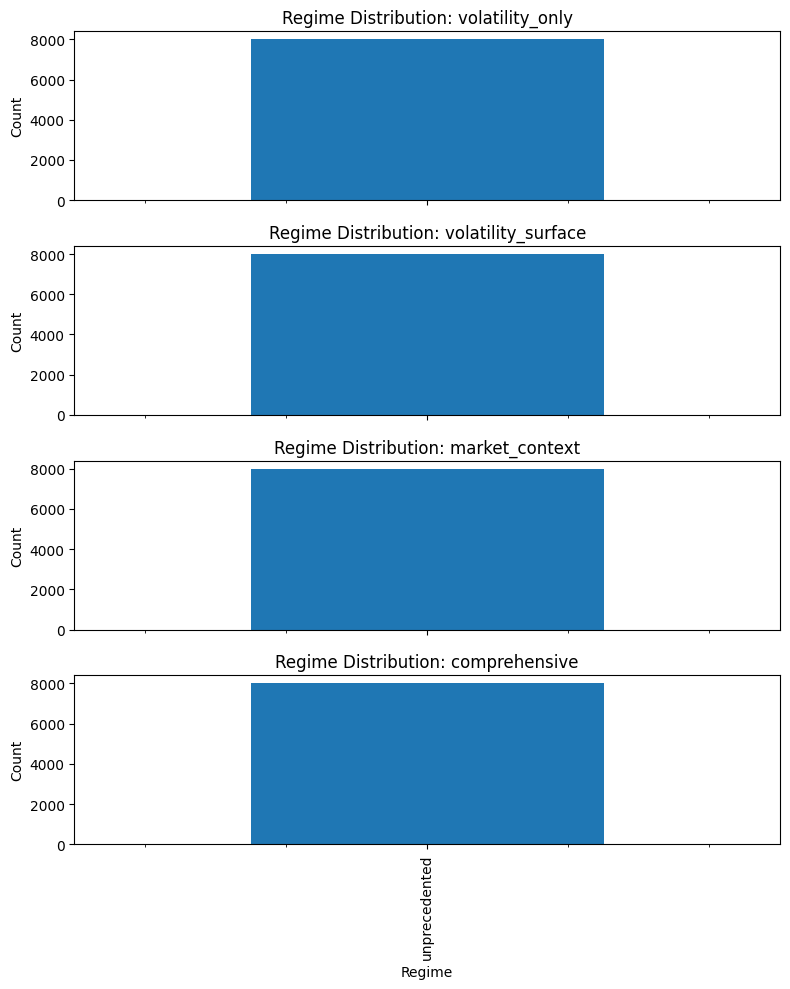

In [14]:
# Plot regime distribution for each feature set
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(results), 1, figsize=(8, 2.5*len(results)), sharex=True)
if len(results) == 1:
    axes = [axes]
for ax, (name, res) in zip(axes, results.items()):
    gmm = res['gmm']
    features = res['features']
    data = historical_data[features].dropna()
    preds = [gmm.predict(row) for row in data.to_dict('records')]
    regimes = [p['regime'] for p in preds]
    pd.Series(regimes).value_counts().sort_index().plot(kind='bar', ax=ax)
    ax.set_title(f'Regime Distribution: {name}')
    ax.set_ylabel('Count')
plt.xlabel('Regime')
plt.tight_layout()
plt.show()

## 3. Time Series Cross-Validation

Let's evaluate the GMM performance using time series cross-validation to ensure it generalizes well.

In [15]:
# Select best performing model
best_model_name = comparison_df['BIC'].idxmin()
best_gmm = results[best_model_name]['gmm']
best_features = results[best_model_name]['features']

print(f"Best model: {best_model_name}")
print(f"Features: {best_features}")

# Prepare data for cross-validation
cv_data = historical_data[best_features].dropna()
cv_data = cv_data.sort_index()

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(cv_data)):
    train_data = cv_data.iloc[train_idx]
    test_data = cv_data.iloc[test_idx]
    
    # Fit on training data
    temp_gmm = GMMRegimeClassifier(n_components=5, random_state=42, feature_cols=best_features)
    temp_gmm.fit(train_data)
    
    # Score on test data
    test_scaled = temp_gmm.scaler.transform(test_data.values)
    test_score = temp_gmm.gmm.score(test_scaled)
    cv_scores.append(test_score)
    
    print(f"Fold {fold+1}: Train samples={len(train_data)}, Test samples={len(test_data)}, Score={test_score:.4f}")

print(f"\nCV Average Score: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

2026-01-27 15:21:04.082 | INFO     | analytics.regime_classifier:fit:475 - GMM fitted with 5 components on 1335 samples
2026-01-27 15:21:04.112 | INFO     | analytics.regime_classifier:fit:475 - GMM fitted with 5 components on 2668 samples
2026-01-27 15:21:04.143 | INFO     | analytics.regime_classifier:fit:475 - GMM fitted with 5 components on 4001 samples
2026-01-27 15:21:04.176 | INFO     | analytics.regime_classifier:fit:475 - GMM fitted with 5 components on 5334 samples
2026-01-27 15:21:04.212 | INFO     | analytics.regime_classifier:fit:475 - GMM fitted with 5 components on 6667 samples


Best model: volatility_only
Features: ['avg_atm_vol', 'roughness']
Fold 1: Train samples=1335, Test samples=1333, Score=-2.0611
Fold 2: Train samples=2668, Test samples=1333, Score=-2.0841
Fold 3: Train samples=4001, Test samples=1333, Score=-2.0700
Fold 4: Train samples=5334, Test samples=1333, Score=-2.0215
Fold 5: Train samples=6667, Test samples=1333, Score=-2.1383

CV Average Score: -2.0750 ± 0.0379


## 4. Regime Prediction and Analysis

Let's analyze the regime predictions over time and their characteristics.

In [16]:
# Generate regime predictions for the entire dataset
predictions = []
probabilities = []

for i in range(len(cv_data)):
    current_point = cv_data.iloc[i:i+1]
    pred = best_gmm.predict(current_point.to_dict('records')[0])
    predictions.append(pred['regime'])
    probabilities.append(pred['probabilities'])

# Add to dataframe
cv_data = cv_data.copy()
cv_data['predicted_regime'] = predictions

# Convert regime names to numeric for analysis
regime_mapping = {regime: i for i, regime in enumerate(np.unique(predictions))}
cv_data['regime_numeric'] = cv_data['predicted_regime'].map(regime_mapping)

print("Regime Distribution:")
print(cv_data['predicted_regime'].value_counts().sort_index())

Regime Distribution:
predicted_regime
unprecedented    8000
Name: count, dtype: int64


In [17]:
# Visualize regime transitions over time
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                   subplot_titles=['ATM Volatility', 'Predicted Regimes'])

# Plot volatility
fig.add_trace(
    go.Scatter(x=cv_data.index, y=cv_data['avg_atm_vol'], 
               mode='lines', name='ATM Vol', line=dict(color='blue')),
    row=1, col=1
)

# Plot regimes
colors = ['red', 'orange', 'yellow', 'green', 'blue']
for i, regime in enumerate(sorted(regime_mapping.keys())):
    mask = cv_data['predicted_regime'] == regime
    fig.add_trace(
        go.Scatter(x=cv_data[mask].index, 
                  y=cv_data[mask]['regime_numeric'],
                  mode='markers', 
                  name=f'Regime {regime}',
                  marker=dict(color=colors[i % len(colors)], size=4)),
        row=2, col=1
    )

fig.update_layout(height=600, title_text="Regime Classification Over Time")
fig.update_yaxes(title_text="ATM Volatility", row=1, col=1)
fig.update_yaxes(title_text="Regime", tickvals=list(regime_mapping.values()), 
                ticktext=list(regime_mapping.keys()), row=2, col=1)
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [18]:
# Analyze regime characteristics
regime_stats = cv_data.groupby('predicted_regime').agg({
    'avg_atm_vol': ['mean', 'std', 'min', 'max'],
    'avg_25d_skew': ['mean', 'std'] if 'avg_25d_skew' in cv_data.columns else 'roughness': ['mean', 'std'],
    'roughness': ['mean', 'std']
}).round(4)

print("Regime Characteristics:")
print(regime_stats)

SyntaxError: invalid syntax (224023238.py, line 4)

## 5. Real-time Testing with Current Market Data

Let's test the model on current market conditions.

In [19]:
# Test with current market data (using synthetic current conditions)
current_market_data = {
    'avg_atm_vol': 0.18,  # Current ATM vol ~18%
    'avg_25d_skew': -0.08,  # Typical skew
    'roughness': 0.06,  # Surface roughness
    'unemployment_rate': 4.2,
    'yield_curve_spread': 0.8,
    'spy_return': 0.001
}

# Filter to available features
current_test = {k: v for k, v in current_market_data.items() if k in best_features}

prediction = best_gmm.predict(current_test)

print("Current Market Regime Prediction:")
print(f"Predicted Regime: {prediction['regime']}")
print(f"Confidence: {prediction['confidence']:.1%}")
print(f"Distribution Fit: {prediction['distribution_fit']}")

print("\nRegime Probabilities:")
for regime, prob in prediction['probabilities'].items():
    print(f"  {regime}: {prob:.1%}")

Current Market Regime Prediction:
Predicted Regime: unprecedented
Confidence: 0.0%
Distribution Fit: 4.33192604484743e-13

Regime Probabilities:
  calm: 0.0%
  pre_stress: 0.0%
  elevated: 0.0%
  acute: 0.0%
  recovery: 0.0%
  unprecedented: 100.0%


## 6. Model Persistence and Deployment

Save the trained model for use in the dashboard.

In [20]:
import pickle
import os

# Save the best model
model_path = '../models/gmm_regime_classifier.pkl'
os.makedirs('../models', exist_ok=True)

with open(model_path, 'wb') as f:
    pickle.dump(best_gmm, f)

print(f"Model saved to {model_path}")
print(f"Features: {best_features}")
print(f"Training samples: {len(cv_data)}")

Model saved to ../models/gmm_regime_classifier.pkl
Features: ['avg_atm_vol', 'roughness']
Training samples: 8000
